## Hola

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import csv
import datetime

from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PolynomialMutation
from pymoo.indicators.hv import Hypervolume

# Definición de parámetros

In [6]:
# --- Parámetros temporales ---
dt = 0.1                              # Paso de integración (s)
tiempo_simulacion = 150               # Duración total de la simulación (s)
t = np.arange(0, tiempo_simulacion, dt)
n = len(t)

# --- Condiciones de operación ---
setpoint = 200.0                      # Temperatura objetivo (°C)
t_init   = 25.0                       # Temperatura inicial del horno (°C)
potencia = 9000                       # Potencia máxima del horno (W)

# --- Modelo FOPDT de la planta (obtenido de prueba de escalón) ---
K_planta    = 2.754                   # Ganancia estática del horno (°C / %)
tau_planta  = 10.0                    # Constante de tiempo (s)
L_planta    = 5.0                     # Tiempo muerto / retardo (s)
pasos_retardo = int(L_planta / dt)    # Retardo expresado en índices

# --- Pesos del índice de rendimiento ---
# w1: penaliza el tiempo de establecimiento (ts)
# w2: penaliza el sobreimpulso máximo    (OS)
# w3: penaliza el error en estado estacionario (ess)
w1, w2, w3 = 1, 2, 1.5

# --- Hypervolume reference point (para análisis posterior del frente de Pareto) ---
punto_referencia = np.array([2.0, 150])  # [rendimiento máximo esperado, consumo máximo esperado]
calculador_hv = Hypervolume(ref_point=punto_referencia)
lista_hv = []  # Para almacenar el hypervolume de cada generación y corrida

# SECCIÓN 2: SIMULACIÓN DEL LAZO CERRADO (PID + PLANTA)

Simula el sistema en lazo cerrado: controlador PID + planta FOPDT.

Parámetros: Kp, Ki, Kd

Retorna:

y -> Temperatura del horno a lo largo del tiempo (°C)

pid -> Señal de control (esfuerzo, 0 % a 100 %)

In [7]:
def simular_lazo_cerrado(Kp: float, Ki: float, Kd: float):
    y        = np.ones(n) * t_init   # Temperatura del horno (°C)
    pid      = np.zeros(n)           # Señal de control (%)
    e        = np.zeros(n)           # Error: setpoint - y
    integral = 0.0                   # Acumulador de la acción integral

    for i in range(1, n - 1):

        # --- Cálculo del error ---
        e[i] = setpoint - y[i]

        # --- Acción del controlador PID ---
        integral   += e[i] * dt
        derivada    = (e[i] - e[i - 1]) / dt
        pid[i]      = (Kp * e[i]) + (Ki * integral) + (Kd * derivada)

        # --- Saturación del actuador (límites físicos del variador) ---
        pid[i] = np.clip(pid[i], 0.0, 100.0)

        # --- Retardo de transporte (tiempo muerto de la planta) ---
        u_retrasada = pid[i - pasos_retardo] if i >= pasos_retardo else 0.0

        # --- Dinámica del horno: ecuación diferencial FOPDT (Euler explícito) ---
        dy_dt   = (K_planta * u_retrasada - (y[i] - t_init)) / tau_planta
        y[i + 1] = y[i] + dy_dt * dt

    return y, pid

In [8]:
def calcular_objetivos(Kp: float, Ki: float, Kd: float):
    """
    Evalúa los dos objetivos de optimización para un conjunto de ganancias.

    Retorna
    -------
    rendimiento : float — Índice combinado (ts, sobreimpulso, ess)  [menor = mejor]
    consumo     : float — Energía consumida en la simulación (kWh)  [menor = mejor]
    """
    y, pid = simular_lazo_cerrado(Kp, Ki, Kd)

    # --- Consumo energético ---
    potencia_instantanea = (pid / 100.0) * potencia          # W
    consumo = (np.sum(potencia_instantanea) * dt) / 3_600_000  # kWh

    # --- Índice de rendimiento de control ---
    max_temp  = np.max(y)
    OS        = max(0.0, max_temp - setpoint)                 # Sobreimpulso
    ess       = abs(setpoint - y[-1])                         # Error estacionario
    banda     = 0.02 * setpoint                               # Banda del ±2 %
    fuera     = np.where(np.abs(y - setpoint) > banda)[0]
    ts        = t[fuera[-1]] if len(fuera) > 0 else t[-1]    # Tiempo de establecimiento

    rendimiento = (w1 * ts) + (w2 * OS) + (w3 * ess)

    return rendimiento, consumo


# Definición de NSAG-II

In [9]:
class OptimizacionPID(ElementwiseProblem):
    """
    Problema de optimización biobjetivo para el controlador PID.

    Variables de decisión : [Kp, Ki, Kd]
    Objetivos             : minimizar [rendimiento, consumo]
    Restricciones         : ninguna (bounds implícitos)
    """

    def __init__(self):
        super().__init__(
            n_var   = 3,
            n_obj   = 2,
            n_constr= 0,
            xl      = np.array([0.0, 0.0, 0.0]),   # Límites inferiores: Kp, Ki, Kd
            xu      = np.array([10.0, 5.0, 5.0])   # Límites superiores: Kp, Ki, Kd
        )

    def _evaluate(self, x, out, *args, **kwargs):
        Kp, Ki, Kd = x
        rendimiento, consumo = calcular_objetivos(Kp, Ki, Kd)
        out["F"] = [rendimiento, consumo] 

# SECCIÓN 4: CONFIGURACIÓN Y EJECUCIÓN DE LA CORRIDA NSGA-II

In [10]:
nombre_archivo_hv = f"registro_hv_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"

# Solo dejamos una configuración
cfg = {"nombre": "Corrida Única (η=20)", "color": "steelblue", "eta": 20}

POP_SIZE  = 100
N_GEN     = 20
SEED      = 1

print("=" * 60)
print("  OPTIMIZACIÓN NSGA-II — PID HORNO INDUSTRIAL")
print("=" * 60)

with open(nombre_archivo_hv, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['Corrida', 'Configuración', 'Semilla', 'Hypervolume'])

print(f"\n  Ejecutando {cfg['nombre']}...")

alg = NSGA2(
    pop_size             = POP_SIZE,
    eliminate_duplicates = True,
    crossover            = SBX(prob=0.9, eta=cfg["eta"]),
    mutation             = PolynomialMutation(prob=0.03, eta=cfg["eta"]),
)

res = minimize(
    OptimizacionPID(),
    alg,
    ("n_gen", N_GEN),
    seed         = SEED,
    save_history = True,
)

frente_pareto = res.F
hv = calculador_hv.do(frente_pareto)

with open(nombre_archivo_hv, 'a', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow([1, cfg['nombre'], SEED, hv])

print("\n  ✓ Optimización finalizada")
print(f"  Hypervolume final: {hv}")
print(f"  Resultados guardados en: {nombre_archivo_hv}")

  OPTIMIZACIÓN NSGA-II — PID HORNO INDUSTRIAL

  Ejecutando Corrida Única (η=20)...

  ✓ Optimización finalizada
  Hypervolume final: 0.0
  Resultados guardados en: registro_hv_20260418_155130.csv


# SECCIÓN 5: ANÁLISIS DE RESULTADOS — EVOLUCIÓN POR GENERACIÓN

In [11]:

sorting = NonDominatedSorting()
gen_data = []
 
for gen_idx, estado in enumerate(res.history):
    F = estado.pop.get("F")   
    X = estado.pop.get("X")   

    nd_indices = sorting.do(F)[0]

    if len(nd_indices) > 0:
        mejor = nd_indices[np.argmin(F[nd_indices, 1])]   
        Kp_v, Ki_v, Kd_v = X[mejor]
        rend_v, cons_v    = F[mejor]

        gen_data.append({
            "Generación":  gen_idx + 1,
            "Kp":          Kp_v,
            "Ki":          Ki_v,
            "Kd":          Kd_v,
            "Consumo":     cons_v,
            "Rendimiento": rend_v,
        })
 
df = pd.DataFrame(gen_data)
 
print(f"\n--- Mejor candidato por generación ---")
print(df.to_string(index=False))
 
last_kp = df["Kp"].iloc[-1]
last_ki = df["Ki"].iloc[-1]
last_kd = df["Kd"].iloc[-1]
 
print(f"\n  Kp final = {last_kp:.4f}")
print(f"  Ki final = {last_ki:.4f}")
print(f"  Kd final = {last_kd:.4f}")


--- Mejor candidato por generación ---
 Generación       Kp       Ki       Kd  Consumo  Rendimiento
          1 2.740484 0.035459 3.228604 0.240506   249.335645
          2 3.900938 0.006217 3.029061 0.226491   203.443875
          3 2.447977 0.006744 0.669876 0.219808   233.087596
          4 2.447977 0.006744 0.685003 0.219585   233.232304
          5 2.173812 0.006744 0.642618 0.217873   226.261556
          6 2.173812 0.006744 0.642618 0.217873   226.261556
          7 2.370119 0.000218 0.407657 0.212306   208.496256
          8 2.308082 0.000544 4.177885 0.210145   175.064374
          9 2.248217 0.000052 0.685003 0.206925   197.161732
         10 2.209719 0.000322 4.208277 0.206300   166.149743
         11 2.167774 0.000218 4.193994 0.205395   160.483679
         12 2.150194 0.000001 4.254846 0.205124   179.050936
         13 1.541693 0.000324 4.177885 0.196774   157.040375
         14 1.541693 0.000324 4.212582 0.196691   162.779616
         15 1.521074 0.000050 4.195632 0.1960

# SECCIÓN 6: SIMULACIÓN FINAL CON LOS PARÁMETROS ÓPTIMOS

In [12]:
y_sim, pid_sim = simular_lazo_cerrado(last_kp, last_ki, last_kd)

# SECCIÓN 7: VISUALIZACIÓN UNIFICADA (UNA SOLA CORRIDA)

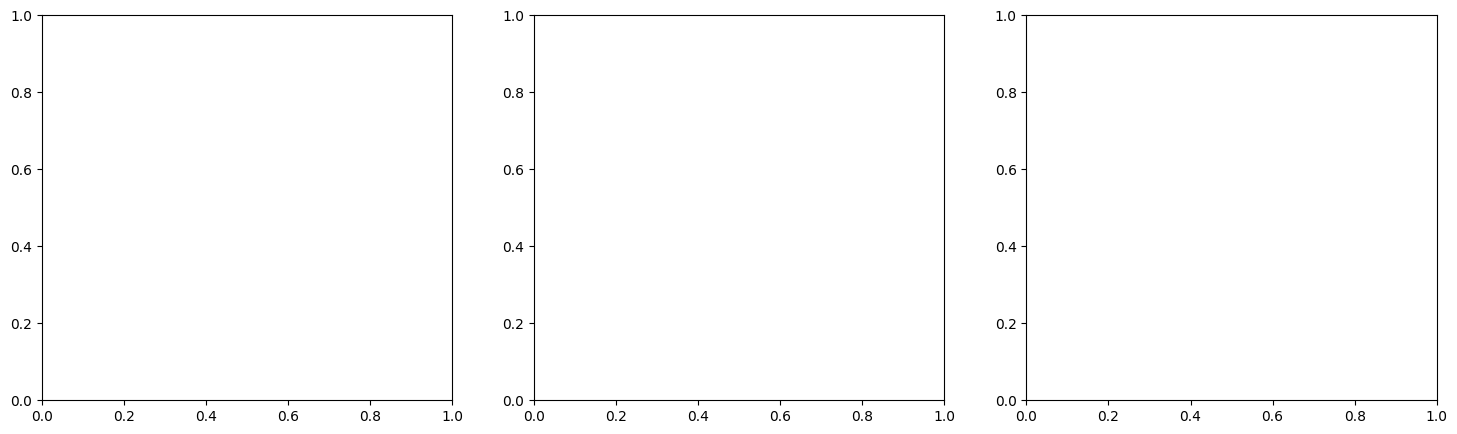

In [18]:
# Creamos la figura y los 3 subgráficos (1 fila, 3 columnas) en un solo paso
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

In [19]:
# ── 1. Frente de Pareto ────────────────────────
ax1.scatter(res_azul.F[:, 1], res_azul.F[:, 0], color=cfg_azul["color"], s=15, label=cfg_azul["nombre"], alpha=0.8)

ax1.set_title(f"Frente: {cfg_azul['nombre']}", fontsize=11)
ax1.set_xlabel("Consumo [kWh]")
ax1.set_ylabel("Rendimiento (menor = mejor)")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(fontsize=9)

NameError: name 'res_azul' is not defined

In [ ]:
# ── 2. Evolución de Parámetros ──────────────────
gens = df["Generación"]
ax2.plot(gens, df["Kp"], color="royalblue",  lw=1.5, marker="o", ms=3, label="Kp")
ax2.plot(gens, df["Ki"], color="darkorange", lw=1.5, marker="s", ms=3, label="Ki")
ax2.plot(gens, df["Kd"], color="seagreen",   lw=1.5, marker="^", ms=3, label="Kd")

ax2.set_title("Evolución de Kp, Ki, Kd", fontsize=11)
ax2.set_xlabel("Generación")
ax2.set_ylabel("Valor del parámetro")
ax2.legend(fontsize=9)
ax2.grid(True, linestyle="--", alpha=0.5)

In [ ]:
# ── 3. Respuesta Temporal ───────────────────────
ax3.plot(t, np.full_like(t, setpoint), "r--", lw=1.2, label="Setpoint")
# Unifiqué la variable a cfg_azul["color"] para evitar errores
ax3.plot(t, y_sim, color=cfg_azul["color"], lw=1.5, label="Temp (°C)")
ax3.plot(t, pid_sim, color="darkorange", lw=1.0, ls="--", label="u(t) [%]")

ax3.set_title(f"Respuesta (Kp={last_kp:.2f}, Ki={last_ki:.2f}, Kd={last_kd:.2f})", fontsize=11)
ax3.set_xlabel("Tiempo (s)")
ax3.set_ylabel("Temp [°C] / Control [%]")
ax3.set_ylim(0, 350)
ax3.legend(fontsize=9, loc="lower right")
ax3.grid(True, linestyle="--", alpha=0.5)

Plot

NameError: name 'cfg_azul' is not defined

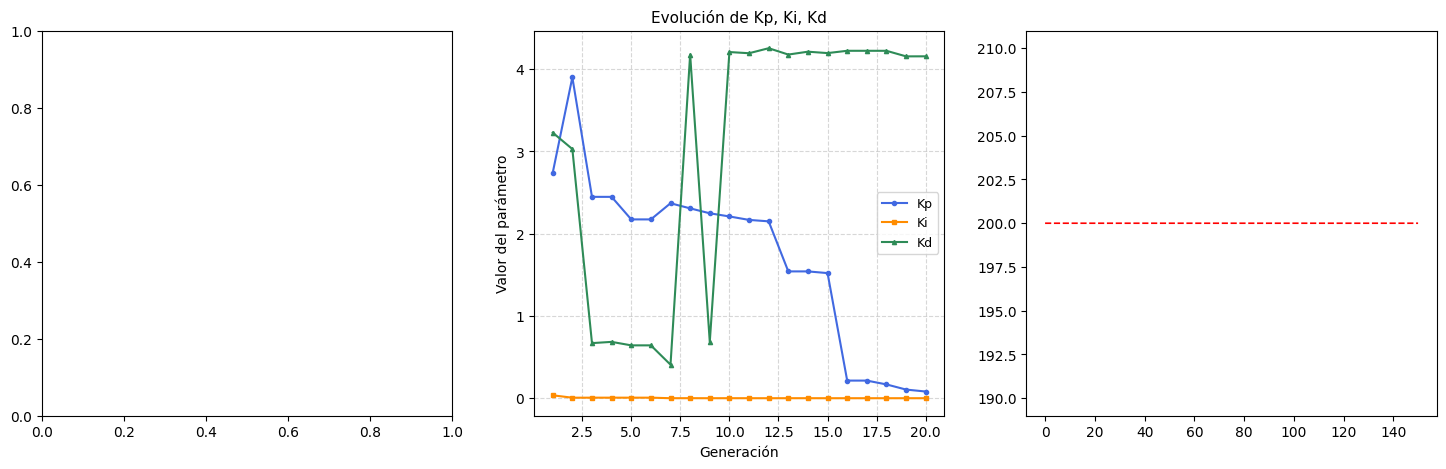

In [ ]:
# Ajusta los márgenes automáticamente para que no se pisen los textos
plt.tight_layout()

# Guarda y muestra
plt.savefig("resultados_nsga2_pid.png", dpi=150, bbox_inches="tight")
plt.show()